# Step 0: Model Training Script

This script trains machine learning models using historical and operational climate forecast datasets to predict hydrologic components and Net Basin Supply (NBS) across the Great Lakes basin.

## Training Data

Model inputs are derived from:

* **Climate Forecast System Reanalysis (CFSR)** data spanning **1979–2010**
* **Climate Forecast System Analysis (CFSA)** forecast data spanning **2011–2024**

## Target Variables

The machine learning models are trained to predict the following hydrologic components simultaneously across all five Great Lakes:

* Precipitation
* Evaporation
* Runoff
* Net Basin Supply (NBS)

Target datasets include:

* **L2SWBM** for precipitation, evaporation, and runoff
* **Great Lakes Coordinating Committee (GLCC)** datasets for NBS

## Modeling Framework

The workflow combines large-scale climate forecast predictors with observed hydrologic targets to train machine learning models capable of subseasonal-to-annual forecasting across the Great Lakes basin. Simultaneous multi-lake training preserves spatial and temporal relationships between lakes and hydrologic processes.


In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
import xgboost as xgb
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import matplotlib.pyplot as plt
import sys
import re
import os
import copy

In [43]:
sys.path.append(os.path.abspath('../../'))
from src.data_processor import CFSTransformer
from src.data_loader import DataLoader
from src.data_processor import SeasonalCycleProcessor
from src.database_utils import CFSDatabase


### Configure Input Paths and Optional Predictors

This cell defines the local repository and input data paths used throughout the workflow. Users should update `local_path` to match the location where the repository was cloned on their system.

Optional predictor datasets, including Great Lakes Surface Temperature (GLSEA SST) and Snow Water Equivalent (SWE), can be enabled or disabled using the `use_sst` and `use_swe` flags (True/False). Corresponding file paths are also specified for loading these datasets into the machine learning feature pipeline.


In [44]:
# ---- Input Paths ---- #

# Local directory where the repository was cloned.
# Update this path to match your local system.
local_path = '/Users/ljob/Desktop/'

# Input directory
input_dir = local_path + 'cnbs-predictor/data/'

# CFSR data
cfsr_file = input_dir + 'cfsr/CFSR_archived_1979-2024.csv'

# ---- Optional Predictor Variables ---- #

# Include Great Lakes Surface Temperature (GLSEA SST) predictors? 
# True/False
use_sst = False

# GLSEA SST input file (Kelvin)
sst_file = input_dir + 'glsea/oisst_sst_1981-2024.csv'

# Include Snow Water Equivalent (SWE) predictors?
# True/False
use_swe = False

# SWE input file
swe_file = input_dir + 'cfsr/CFSR_SWE_Basin_mm.csv'

## Begin Script

### Feature Construction Workflow

This script prepares the feature dataset for model training by integrating precipitation, evaporation, air temperature, and lake surface temperature data. The workflow is as follows:

#### 1. Read Reanalysis Data from CFSR
- **Precipitation (PCP, mm)**
- **Evaporation (EVAP, mm)** 
- **Air Temperature (TMP, K)** 

#### 2. Assemble Feature Matrix (`X`)
- Construct a DataFrame containing lake- and land-specific values for each Great Lake (Superior, Michigan-Huron, Erie, Ontario).  
- Variables include precipitation, evaporation, and air temperature for both **over-lake** and **over-land** domains.

#### 3. Create Forecast-Like Features
- Apply `CFSProcessor.shift_variables` to generate lead times from **0 to 9 months** for each variable to replicate a 9-month CFS forecast.

#### 4. Include Seasonality and Temporal Features
* Extract the calendar month from the datetime index.
* Encode seasonality using cyclic temporal features:

  * `month_sin`
  * `month_cos`

These cyclical variables preserve the continuous seasonal relationship between months (e.g., December transitions smoothly into January) and avoid artificial discontinuities introduced by one-hot encoding (i.e., month_1 = True).

* Include a continuous `time` feature representing long-term temporal progression to help smooth forecasts and capture gradual trends and low-frequency variability over time.


#### 5. Reorder Features
* Columns are reorganized to ensure a consistent feature ordering for model training and inference:
  1. Temporal features:
     * `time`
     * `month_sin`
     * `month_cos`
  2. Basin-specific predictor variables for:
     * precipitation
     * evaporation
     * air temperature
     across all forecast lead times (`mo0` … `mo9`).


#### 6. Optional Additional Features for Current-State Initialization

Additional predictor variables may optionally be included to provide the machine learning models with information about the current hydrologic and thermal state of the Great Lakes basin.

Optional datasets include:

* **Great Lakes Surface Environmental Analysis (GLSEA)** lake surface temperature (SST) data (`oisst_sst_1981-2024.csv`) in Kelvin
* **Snow Water Equivalent (SWE)** datasets derived from CFSR (`CFSR_SWE_Basin_mm.csv`)

These variables are merged with the reorganized predictor matrix to produce the final feature dataset (`X_merged`). Inclusion of SST and SWE predictors helps improve representation of basin memory, antecedent conditions, and seasonal persistence within the forecasting framework.

#### 7. Feature Table Example

| Feature Category       | Example Feature Names                                                       |
| ---------------------- | --------------------------------------------------------------------------- |
| Temporal Features      | `time`, `month_sin`, `month_cos`                                            |
| SST (Optional)         | `superior_sst`, `michigan-huron_sst`, `erie_sst`, `ontario_sst`             |
| SWE (Optional)         | `superior_swe`, `michigan-huron_swe`, `erie_swe`, `ontario_swe`             |
| Precipitation (Lake)   | `superior_lake_precipitation_mo0` ... `superior_lake_precipitation_mo9`     |
| Precipitation (Land)   | `superior_land_precipitation_mo0` ... `superior_land_precipitation_mo9`     |
| Evaporation (Lake)     | `superior_lake_evaporation_mo0` ... `superior_lake_evaporation_mo9`         |
| Evaporation (Land)     | `superior_land_evaporation_mo0` ... `superior_land_evaporation_mo9`         |
| Air Temperature (Lake) | `superior_lake_air_temperature_mo0` ... `superior_lake_air_temperature_mo9` |
| Air Temperature (Land) | `superior_land_air_temperature_mo0` ... `superior_land_air_temperature_mo9` |


In [45]:
swe_database = '/Users/ljob/Desktop/Data/CFSR/cfsr_swe_archive.db'
cfsr_table = 'cfsr_archive'
swe_data = CFSDatabase(swe_database, cfsr_table).load()
swe_data = swe_data[swe_data["surface_type"] != "lake"] # Remove lake data from SWE dataset

runoff_database = '/Users/ljob/Desktop/Data/CFSR/cfsr_runoff_archive.db'
runoff_data = CFSDatabase(runoff_database, cfsr_table).load()
runoff_data = runoff_data[runoff_data["surface_type"] != "lake"] # Remove lake data from runoff dataset

sp_database = '/Users/ljob/Desktop/Data/CFSR/cfsr_pressure_archive.db'
sp_data = CFSDatabase(sp_database, cfsr_table).load()

In [46]:
dfs = [swe_data, runoff_data, sp_data]

df_combined = pd.concat(dfs, ignore_index=True)

# Sort by year, month, and lake
df_combined = df_combined.sort_values(
    by=["year", "month", "lake"]
).reset_index(drop=True)

print(df_combined.head())

   year  month            lake surface_type         component         value
0  1979      1            erie         land               swe     31.595913
1  1979      1            erie         land            runoff      0.214750
2  1979      1            erie         lake  surface_pressure  99247.666667
3  1979      1            erie         land  surface_pressure  98214.177632
4  1979      1  michigan-huron         land               swe     90.147737


In [47]:
# Create YYYY-MM-01 date
df_combined["date"] = pd.to_datetime(
    df_combined[["year", "month"]].assign(day=1)
).dt.strftime("%Y-%m-%d")

# Create variable name
df_combined["variable"] = (
    df_combined["lake"] + "_" +
    df_combined["surface_type"] + "_" +
    df_combined["component"]
)

# Pivot
df_pivot = (
    df_combined
    .pivot(
        index="date",
        columns="variable",
        values="value"
    )
    .reset_index()
)

# Remove the columns name left over from the pivot
df_pivot.columns.name = None

In [48]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1979-01-01'
train_end_date = '2004-12-31'

# Testing dataset
val_start_date = '2005-01-01'
val_end_date = '2010-12-01'

# Training and validation slices
train_slice = slice(train_start_date, train_end_date)
val_slice   = slice(val_start_date, val_end_date)

# Read in data from CFSR
data = pd.read_csv(cfsr_file,sep=',')

# Features
X = pd.DataFrame({
    'date': data['date'],
    'superior_lake_precipitation':  data['superior_lake_precipitation'],
    'michigan-huron_lake_precipitation': data['michigan-huron_lake_precipitation'],
    'erie_lake_precipitation': data['erie_lake_precipitation'],
    'ontario_lake_precipitation': data['ontario_lake_precipitation'],
    'superior_land_precipitation': data['superior_land_precipitation'],
    'michigan-huron_land_precipitation': data['michigan-huron_land_precipitation'],
    'erie_land_precipitation': data['erie_land_precipitation'],
    'ontario_land_precipitation': data['ontario_land_precipitation'],
    'superior_lake_evaporation': data['superior_lake_evaporation'],
    'michigan-huron_lake_evaporation': data['michigan-huron_lake_evaporation'],
    'erie_lake_evaporation': data['erie_lake_evaporation'],
    'ontario_lake_evaporation': data['ontario_lake_evaporation'],
    'superior_land_evaporation': data['superior_land_evaporation'],
    'michigan-huron_land_evaporation': data['michigan-huron_land_evaporation'],
    'erie_land_evaporation': data['erie_land_evaporation'],
    'ontario_land_evaporation': data['ontario_land_evaporation'],
    'superior_lake_air_temperature': data['superior_lake_air_temperature'],
    'michigan-huron_lake_air_temperature': data['michigan-huron_lake_air_temperature'],
    'erie_lake_air_temperature': data['erie_lake_air_temperature'],
    'ontario_lake_air_temperature': data['ontario_lake_air_temperature'],
    'superior_land_air_temperature': data['superior_land_air_temperature'],
    'michigan-huron_land_air_temperature': data['michigan-huron_land_air_temperature'],
    'erie_land_air_temperature': data['erie_land_air_temperature'],
    'ontario_land_air_temperature': data['ontario_land_air_temperature'],
    'superior_land_swe': df_pivot['superior_land_swe'],
    'michigan-huron_land_swe': df_pivot['michigan-huron_land_swe'],
    'erie_land_swe': df_pivot['erie_land_swe'],
    'ontario_land_swe': df_pivot['ontario_land_swe'],
    'superior_land_runoff': df_pivot['superior_land_runoff'],
    'michigan-huron_land_runoff': df_pivot['michigan-huron_land_runoff'],
    'erie_land_runoff': df_pivot['erie_land_runoff'],
    'ontario_land_runoff': df_pivot['ontario_land_runoff'],
    'superior_land_pressure': df_pivot['superior_land_surface_pressure'],
    'michigan-huron_land_pressure': df_pivot['michigan-huron_land_surface_pressure'],
    'erie_land_pressure': df_pivot['erie_land_surface_pressure'],
    'ontario_land_pressure': df_pivot['ontario_land_surface_pressure'],
    'superior_lake_pressure': df_pivot['superior_lake_surface_pressure'],
    'michigan-huron_lake_pressure': df_pivot['michigan-huron_lake_surface_pressure'],
    'erie_lake_pressure': df_pivot['erie_lake_surface_pressure'],
    'ontario_lake_pressure': df_pivot['ontario_lake_surface_pressure']
})

# Set the index by date
X = X.set_index(pd.to_datetime(X['date'])).drop(columns='date')

In [49]:
X = X.dropna()  # Drop rows with NaN values
print(X)

            superior_lake_precipitation  michigan-huron_lake_precipitation  \
date                                                                         
1979-01-01                    65.888903                          98.979232   
1979-02-01                    72.947135                          55.946494   
1979-03-01                   140.381977                         124.561790   
1979-04-01                    82.937371                         127.197408   
1979-05-01                   119.764162                          96.168734   
...                                 ...                                ...   
2010-08-01                    73.812490                          42.007324   
2010-09-01                   136.260607                         100.273292   
2010-10-01                    78.482199                          63.607408   
2010-11-01                    97.296494                          76.973826   
2010-12-01                    52.680542                         

### Remove the Seasonal Cycle and Calculate Anomalies

This step calculates the climatological seasonal cycle for each predictor variable using the training-period data only. Monthly means are computed for every variable to represent the expected seasonal baseline conditions.

The fitted seasonal climatology is then saved for reproducibility and future inference workflows. After fitting, the seasonal cycle is removed from the full dataset to generate anomaly-based predictors (`X_anom`).

Using anomalies instead of absolute values helps reduce strong seasonal dominance in the predictors and allows the machine learning models to better learn departures from typical conditions, including interannual variability and extreme hydrologic events.


In [50]:
# Fit seasonal cycle
scp_X = SeasonalCycleProcessor().fit(
    X,
    var_list=list(X.columns),
    baseline_time=train_slice,
    baseline_definition={
        "train_start" : train_start_date,
        "train_end" : train_end_date
    }
)

# Save the fitted seasonal cycle processor for later use
paths = scp_X.save(input_dir + "input/climatology/inputs")

# Transform the full dataset
X_anom = scp_X.transform(X)

       superior_lake_precipitation  michigan-huron_lake_precipitation  \
month                                                                   
1                        74.504235                          82.092343   
2                        58.647834                          67.564700   
3                        77.558803                          88.849330   
4                        80.802480                          99.315358   
5                        90.854759                          97.857633   
6                        83.753728                          86.414097   
7                        71.587008                          64.445114   
8                        53.282535                          65.851386   
9                        74.944053                          79.438154   
10                       95.570809                          83.495978   
11                       84.343412                          98.338272   
12                       74.016449                 

### Create Lead-Time Predictor Variables

This step separates optional current-state variables (`SST` and `SWE`) from the climate forecast predictors prior to generating lead-time features.

If enabled by the user configuration (`use_sst=True` and/or `use_swe=True`), lake surface temperature (_sst) and snow water equivalent (_swe) variables are retained at their initialization timestep because they represent current basin conditions at forecast initialization. These variables are not shifted into future lead times.

All remaining forecast predictor variables are shifted to generate lead-time features from 0 to 9 months ahead. The shifted predictors are then merged back together with the optional SST and SWE variables to create the final lead-time predictor matrix.

In [51]:
# Shift forecast variables to create predictor features
# spanning lead times from 0 to 9 months ahead.
X_shifted = CFSTransformer(X_anom).shift_variables(
    lag=0,
    lead=10
)


### Verify Native and Anomaly Predictor Data

This diagnostic plot compares the original predictor time series with its anomaly-transformed counterpart after seasonal cycle removal.

The raw series (`X`) represents the native predictor values, while the anomaly series (`X_anom`) represents departures from the climatological monthly mean. This visualization provides a simple quality-control check to confirm that the seasonal cycle was successfully removed while preserving interannual variability and anomalous events.


### Add Temporal Features and Reorder Predictors

This step adds temporal features to the predictor matrix, including `time`, `month_sin`, and `month_cos`. These variables help the model represent long-term temporal progression and smooth seasonal variability across months.

The feature columns are then reorganized into a consistent order for model training and inference. Optional current-state predictors, including SST and SWE, are only included if they were enabled in the user configuration.

In [52]:
# Add time, month_sin, and month_cos features
X_time = CFSTransformer(X_shifted).add_time_features()

# Always include temporal features first
feature_column_order = [
    'time',
    'month_sin',
    'month_cos'
]

# Add lead-time CFS predictor variables
feature_column_order += [
    f'{lake}_{surface_type}_{comp}_mo{m}'
    for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
    for surface_type in ['lake', 'land']
    for comp in ['precipitation', 'evaporation', 'air_temperature', 'pressure']
    for m in range(10)
]

feature_column_order += [
    f'{lake}_{surface_type}_{comp}_mo{m}'
    for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
    for surface_type in ['land']
    for comp in ['swe', 'runoff']
    for m in range(10)
]

# Keep only columns that exist in X_time.
# This makes the workflow robust if optional features are disabled.
feature_column_order = [
    col for col in feature_column_order
    if col in X_time.columns
]

X_reorg = X_time[feature_column_order]

## Target Construction Workflow

This script prepares the target dataset for model training, including precipitation, evaporation, runoff, and net basin supply (NBS) for each Great Lake. The workflow is as follows:

### 1. Load L2SWBM Data
- Source: [L2SWBM dataset](https://zenodo.org/records/13883098)  
- Required file format for each lake (erie, miHuron, ontario, superior):  
  - Evaporation: `{lake}Evap_MonthlyRun.csv`  
  - Precipitation: `{lake}Precip_MonthlyRun.csv`  
  - Runoff: `{lake}Runoff_MonthlyRun.csv`  
- Each loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `{lake}_{component}_obs` (e.g., `erie_precipitation_obs`) for each lake and component.

### 2. Load GLCC Data
- Source: Great Lakes Coordinating Committee (GLCC)  
- Required file format for each lake (Erie, MichiganHuron, Ontario, Superior):  
  - `Lake{lake}_MonthlyNetBasinSupply_1900to2025.csv`  
- Loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `lake_nbs_obs` for each lake.

### 3. Assemble Target Matrix (`targets`)
- Combine L2SWBM components (precipitation, evaporation, runoff) with GLCC NBS for each lake into a single DataFrame.  
- Column naming convention: `{lake}_target_{component}` (e.g., `superior_target_evaporation`).  
- Only keep rows where **all target values are available** by dropping any rows with missing data.

### 4. Create Forecast-Like Lead Variables
- Apply `CFSProcessor.shift_variables` to generate **lead versions of all targets**, to minic the targeted **12-month forecast horizon** (lead times 0–11).

### 5. Reorder Target Columns
- Columns are organized to ensure a consistent structure for modeling:  

```text
superior_target_precipitation_mo0 … mo11
superior_target_evaporation_mo0 … mo11
superior_target_runoff_mo0 … mo11
superior_target_nbs_mo0 … mo11
michigan-huron_target_precipitation_mo0 … mo11
michigan-huron_target_evaporation_mo0 … mo11
...
ontario_target_nbs_mo0 … mo11


In [53]:
dataloader = DataLoader()

# Load L2SWBM data
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')

# Load GLCC data
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

targets_shifted = CFSTransformer(targets).shift_variables(lag=0, lead=12)

### Remove the Seasonal Cycle from Target Variables

This step calculates the climatological seasonal cycle for the target variables using the training-period data only in order to avoid data leakage into the validation and forecast periods.

Monthly climatological means are calculated for each target variable and used to define the expected seasonal baseline conditions. The fitted climatology is then removed from the full target dataset to generate anomaly-based target variables (`targets_anom`).

The resulting climatology artifacts are saved to disk so the identical seasonal baseline can be applied consistently during operational forecasting and inverse transformation back to native units.

In [54]:
# 1) Fit monthly climatology on TRAIN ONLY (avoid leakage)
scp_y = SeasonalCycleProcessor().fit(
    targets,
    var_list=list(targets.columns),          # explicit is good here
    baseline_time=train_slice,
    baseline_definition={
        "train_start": train_start_date,
        "train_end": train_end_date,
        "note": "targets climatology fit on training period only"
    },
)

# 2) Transform full targets to anomalies
targets_anom = scp_y.transform(targets)

# Save artifact so forecast notebook can load the same baseline
paths = scp_y.save(input_dir + "input/climatology/targets")

       superior_target_evaporation  superior_target_precipitation  \
month                                                               
1                       102.926306                      51.950000   
2                        57.909227                      33.624231   
3                        42.737679                      43.300385   
4                        16.582891                      53.876154   
5                         2.531784                      70.174231   
6                        -2.347928                      78.368077   
7                         0.115527                      78.981923   
8                        12.203915                      76.183462   
9                        47.558434                      81.921154   
10                       72.643267                      76.960769   
11                      100.147528                      61.286923   
12                      116.198066                      52.439231   

       superior_target_runoff  su

### Verify Native and Anomaly Target Data

This diagnostic plot compares the original target variable time series with its anomaly-transformed counterpart after seasonal cycle removal.

The raw target series (`targets`) represents the native hydrologic values, while the anomaly series (`targets_anom`) represents departures from the climatological monthly mean calculated from the training period. This visualization serves as a quality-control check to confirm that the seasonal cycle was successfully removed while preserving interannual variability and anomalous hydrologic events.

### Create Lead-Time Target Variables

This step converts the anomaly-based target variables into lead-time forecast targets spanning 12 months ahead.

Target variables are shifted to create forecast lead times from `mo0` through `mo11`, representing the full 12-month prediction horizon for each lake and hydrologic component. The resulting target columns are then reorganized into a consistent ordering to ensure compatibility with machine learning training, validation, and forecasting workflows.


In [55]:
# Shift the targets to create lead variables
targets_lead = CFSTransformer(targets_anom).shift_variables(lag=0, lead=12)

# Define the target column order for the 12-month forecast
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

# Reorganize the targets DataFrame to match the target column order
targets_reorg = targets_lead.reindex(columns=target_column_order)

## Align Features and Targets

This step ensures that the **features** and **target** datasets are aligned:  

### 1. Subset the reorganized target DataFrame (`targets_reorg`) to only include rows corresponding to the **dates present in the merged feature dataset** (`X_merged`).  
   - This guarantees that each row of features has a matching target for model training.  
   - The aligned target dataset is stored in `aligned_y`.

### 2. Print summary information for verification:  
   - **Number of features** (`X_merged.shape[1]`)  
   - **Number of target variables** (`aligned_y.shape[1]`)  

This alignment is crucial for ensuring consistent input-output pairing before training or forecasting.


In [56]:
# Make sure the features and target indices/dates align
aligned_X, aligned_y = X_reorg.align(targets_reorg, join='inner', axis=0)
print(f'Number of Features: {aligned_X.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 403
Number of Targets: 192


## Train-Test Split by Date

This step divides the dataset into **training** and **testing** subsets based on date ranges, rather than random sampling, to **preserve seasonal and temporal structure**:  

### 1. **Training Set (≈80% of data)**  
   - Start: January 1982  
   - End: December 2005  
   - `X_train` and `y_train` contain features and targets within this range.  

### 2. **Testing/Validation Set (≈20% of data)**  
   - Start: January 2006  
   - End: January 2011  
   - `X_test` and `y_test` contain features and targets within this range.  

This chronological split ensures that the model is evaluated on **future data**, maintaining realistic forecasting conditions and seasonal patterns.


In [57]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

## Feature and Target Standardization

This step standardizes the features and targets to improve model training and convergence:  

### 1. **Define Scalers**  
   - `x_scaler` and `y_scaler` are instances of `StandardScaler` from `scikit-learn`.  

### 2. **Fit and Transform Training Data**  
   - The scalers are **fit only on the training data** to avoid data leakage.  
   - `X_train_scaled` and `y_train_scaled` contain standardized training features and targets.  

### 3. **Transform Testing Data**  
   - Apply the same fitted scalers to the testing data (`X_test_scaled` and `y_test_scaled`) to ensure consistent scaling.  

### 4. **Save Scalers for Future Use**  
   - The fitted scalers are saved using `joblib.dump` so they can be applied during the **prediction phase** on new data, maintaining the same scaling.


In [70]:
# Define the scaler we want to use
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Standardize the data
# This will scale the features and targets between 0 and 1
# Scale X while preserving column names and index
X_train_scaled = pd.DataFrame(
    x_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    x_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# Scale y while preserving column names and index
y_train_scaled = pd.DataFrame(
    y_scaler.fit_transform(y_train),
    columns=y_train.columns,
    index=y_train.index
)

y_test_scaled = pd.DataFrame(
    y_scaler.transform(y_test),
    columns=y_test.columns,
    index=y_test.index
)

# Save the scalers to use later during the prediction phase
joblib.dump(x_scaler, input_dir + 'input/scalers/x_scaler_anom.joblib')
joblib.dump(y_scaler, input_dir + 'input/scalers/y_scaler_anom.joblib')

['/Users/ljob/Desktop/cnbs-predictor/data/input/scalers/y_scaler_anom.joblib']

## Gaussian Process Regression (GPR) Model Setup, Training and Evaluation

This step defines, trains, and evaluates a **Gaussian Process Regression (GPR)** model using the preprocessed features and targets.  

### 1. Kernel Selection
- Several kernel options are explored for modeling:  
  - **Basic kernel:** `ConstantKernel * RBF`  
  - **Matt's optimal kernel:** `1.0 * Matern(nu=1.5) * RationalQuadratic()` (currently used)  
  - Optional seasonal components: `ExpSineSquared` for modeling periodicity, or combinations of `RBF`, `Matern`, and `RationalQuadratic`.  

### 2. Model Definition
- Initialize the GPR model with the selected kernel.  
- Parameters:  
  - `alpha=0.1` → observation noise level  
  - `n_restarts_optimizer=10` → number of restarts for kernel hyperparameter optimization  
  - `random_state=42` → ensures reproducibility  

### 3. Model Training
- Fit the GPR model on the **scaled training data** (`X_train_scaled` and `y_train_scaled`).  
- Save the trained model using `joblib` for future use.

### 4. Predictions and Evaluation
- Predict on the **scaled testing features** (`X_test_scaled`) and obtain uncertainty estimates (`sigma`).  
- Compute **R² score** on the testing data to evaluate model performance:  
  ```python
  r2 = r2_score(y_test_scaled, y_pred_GP)

(The function below should be added to the data processor)

In [71]:
# Testing Different Kernels
# Basic kernel using ConstantKernel:
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Matt's optimal kernel: 
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

#kernel = 1.0 * Matern(length_scale=50.0, nu=1.5, length_scale_bounds=(1e-10, 1e3)) \
#         * RationalQuadratic(alpha=0.0001, length_scale=.01, length_scale_bounds=(1e-10, 1e3))

# Test to add a seasonality component:
#period = 3.0  # Period of the season
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + ExpSineSquared(length_scale=1.0, periodicity=period, periodicity_bounds=(1e-2, 1e2))

# Set up the model
gpr_model = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

# Fit the model
gpr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(gpr_model, input_dir + 'input/models/GP_trained_model_anom.joblib')

# Predictions
y_pred_GP, sigma = gpr_model.predict(X_test_scaled, return_std=True)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_GP)

print(f"R² Score: {r2:.4f}")
# Optimized kernel after training
print("Optimized Kernel:", gpr_model.kernel_)

# Kernel hyperparameters
print("Kernel Hyperparameters:", gpr_model.kernel_.theta)

R² Score: 0.3995
Optimized Kernel: 1.67**2 * Matern(length_scale=40.7, nu=1.5) * RationalQuadratic(alpha=0.0254, length_scale=4.01e+04)
Kernel Hyperparameters: [ 1.03029997  3.70513187 -3.67361646 10.59956117]


In [60]:
def unscale_to_df(y_std, scaler, index, columns):
    return pd.DataFrame(scaler.inverse_transform(y_std), index=index, columns=columns)

def r2_flat(a, b):
    return r2_score(a.to_numpy().ravel(), b.to_numpy().ravel())

# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_GP,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.4334731712387744
R² (absolute, reconstructed): 0.8085295562947646
R² (absolute, climatology-only): 0.6611664653314804


In [72]:
import xgboost as xgb

# Create the XGBoost regressor 
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'  # for regression
)

# Train the model
xgb_model.fit(X_train_scaled, y_train_scaled)

# Predict on the test set
y_pred_XGB = xgb_model.predict(X_test_scaled)

# Save the trained model
joblib.dump(xgb_model, input_dir + 'input/models/XGB_trained_model_anom.joblib')

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_XGB)

print(f"R² Score: {r2:.4f}")

R² Score: 0.4044


In [62]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_XGB,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.41696313701855026
R² (absolute, reconstructed): 0.802949620063594
R² (absolute, climatology-only): 0.6611664653314804


In [73]:
## Random Forest Regressor Model:

# Initialize RandomForestRegressor
rfr_model = skRFR(random_state=42)

# Train the model
trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_RFR, input_dir + 'input/models/RF_trained_model_anom.joblib')

# Predict on the test set
y_pred_RFR = trained_RFR.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_RFR)

print(f"R² Score: {r2:.4f}")

R² Score: 0.0378


In [64]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_RFR,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.12641426237157993
R² (absolute, reconstructed): 0.7047521135688765
R² (absolute, climatology-only): 0.6611664653314804


(312, 403) (312, 192)
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.1686 - mae: 0.8295 - val_loss: 1.0275 - val_mae: 0.7741
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0128 - mae: 0.7650 - val_loss: 0.9913 - val_mae: 0.7584
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9774 - mae: 0.7503 - val_loss: 0.9798 - val_mae: 0.7534
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9573 - mae: 0.7428 - val_loss: 0.9753 - val_mae: 0.7521
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9364 - mae: 0.7356 - val_loss: 0.9729 - val_mae: 0.7519
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9127 - mae: 0.7274 - val_loss: 0.9710 - val_mae: 0.7518
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8853 - mae: 0.7177 - val_loss: 0.9674 - val_mae: 0.7503
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8556 - mae: 0.7065 - val_loss: 0.9638 - val_mae: 0.7491
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8251 - 

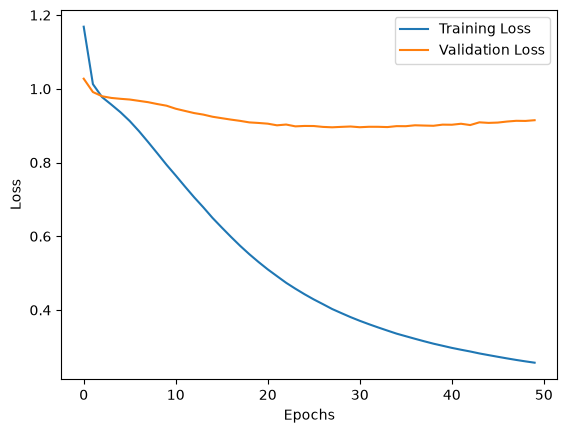

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/stepWARNING:tensorflow:5 out of the last 289 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x31049b6a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
R² Score: 0.0517


In [74]:
## Neural Network ##

# Define the neural network architecture
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using mean squared error (mse) as the loss function

print(X_train_scaled.shape, y_train_scaled.shape)
# Fit the model to the training data
history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)#, callbacks=[early_stopping])

# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
joblib.dump(nn_model, input_dir + 'input/models/NN_trained_model_anom.joblib')

# Predict on the test set
y_pred_NN = nn_model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_NN)

print(f"R² Score: {r2:.4f}")

In [66]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import mean_squared_error


# ============================================================
# 1. PARSE FEATURE NAMES
# ============================================================

def parse_feature_name(feature):
    """
    Parse a feature name into its physical components.

    Examples
    --------
    erie_land_precipitation_mo3
    superior_lake_air_temperature_mo5
    ontario_land_swe_mo2

    Returns
    -------
    dict
    """

    # Temporal features
    if feature == "time":
        return {
            "feature": feature,
            "lake": None,
            "surface_type": None,
            "component": "temporal",
            "lead": None
        }

    if feature == "month_sin":
        return {
            "feature": feature,
            "lake": None,
            "surface_type": None,
            "component": "temporal",
            "lead": None
        }

    if feature == "month_cos":
        return {
            "feature": feature,
            "lake": None,
            "surface_type": None,
            "component": "temporal",
            "lead": None
        }

    pattern = (
        r"^(superior|michigan-huron|erie|ontario)_"
        r"(lake|land)_"
        r"(precipitation|evaporation|air_temperature|pressure|swe|runoff)_"
        r"mo(\d+)$"
    )

    match = re.match(pattern, feature)

    if match:

        lake, surface_type, component, lead = match.groups()

        return {
            "feature": feature,
            "lake": lake,
            "surface_type": surface_type,
            "component": component,
            "lead": int(lead)
        }

    raise ValueError(
        f"Could not parse feature name: {feature}"
    )


# ============================================================
# 2. CREATE FEATURE INFORMATION DATAFRAME
# ============================================================

def create_feature_info(feature_names):
    """
    Create a dataframe containing metadata for every feature.
    """

    rows = [
        parse_feature_name(feature)
        for feature in feature_names
    ]

    return pd.DataFrame(rows)


# ============================================================
# 3. CREATE FEATURE GROUPS
# ============================================================

def create_feature_groups(
    feature_names,
    group_by="component"
):
    """
    Create groups of features for grouped permutation importance.

    Parameters
    ----------
    feature_names : list
        Names of model input features.

    group_by : str
        Options:

        'feature'
            Every feature is its own group.

        'component'
            precipitation, evaporation, temperature, etc.

        'lake'
            Superior, Michigan-Huron, Erie, Ontario.

        'surface'
            lake vs land.

        'lead'
            mo0, mo1, ..., mo9.

        'lake_component'
            e.g. erie_precipitation.

        'component_lead'
            e.g. precipitation_mo3.

        'lake_surface'
            e.g. erie_land.

        'lake_component_lead'
            Individual physical predictor group.

    Returns
    -------
    dict
        {group_name: [feature indices]}
    """

    info = create_feature_info(feature_names)

    groups = {}

    for i, row in info.iterrows():

        if group_by == "feature":

            group_name = row["feature"]

        elif group_by == "component":

            group_name = row["component"]

        elif group_by == "lake":

            group_name = row["lake"]

            if pd.isna(group_name):
                group_name = "temporal"

        elif group_by == "surface":

            group_name = row["surface_type"]

            if pd.isna(group_name):
                group_name = "temporal"

        elif group_by == "lead":

            if pd.isna(row["lead"]):
                group_name = "temporal"

            else:
                group_name = f"mo{int(row['lead'])}"

        elif group_by == "lake_component":

            if pd.isna(row["lake"]):
                group_name = "temporal"

            else:
                group_name = (
                    f"{row['lake']}_{row['component']}"
                )

        elif group_by == "component_lead":

            if pd.isna(row["lead"]):

                group_name = "temporal"

            else:

                group_name = (
                    f"{row['component']}_mo{int(row['lead'])}"
                )

        elif group_by == "lake_surface":

            if pd.isna(row["lake"]):

                group_name = "temporal"

            else:

                group_name = (
                    f"{row['lake']}_{row['surface_type']}"
                )

        elif group_by == "lake_component_lead":

            if pd.isna(row["lake"]):

                group_name = "temporal"

            else:

                group_name = (
                    f"{row['lake']}_"
                    f"{row['surface_type']}_"
                    f"{row['component']}_"
                    f"mo{int(row['lead'])}"
                )

        else:

            raise ValueError(
                f"Unknown group_by option: {group_by}"
            )

        if group_name not in groups:
            groups[group_name] = []

        groups[group_name].append(i)

    return groups


# ============================================================
# 4. GROUPED PERMUTATION IMPORTANCE
# ============================================================

def grouped_permutation_importance(
    model,
    X,
    y,
    group_by="component",
    n_repeats=10,
    random_state=42
):
    """
    Calculate grouped permutation importance.

    The features in each group are shuffled using the SAME
    permutation. This preserves the relationships among features
    within a group while removing the group's information from
    the model.

    Importance is measured as the increase in RMSE.

    Parameters
    ----------
    model : trained model
        Must have a .predict() method.

    X : pandas.DataFrame
        Validation/test features.

    y : pandas.DataFrame or numpy array
        Validation/test targets.

    group_by : str
        Grouping strategy.

    n_repeats : int
        Number of permutations for each group.

    random_state : int
        Random seed.

    Returns
    -------
    pandas.DataFrame
    """

    if not isinstance(X, pd.DataFrame):

        X = pd.DataFrame(
            X,
            columns=[
                f"feature_{i}"
                for i in range(X.shape[1])
            ]
        )

    # --------------------------------------------------------
    # Baseline prediction
    # --------------------------------------------------------

    baseline_prediction = model.predict(X)

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y,
            baseline_prediction
        )
    )

    # --------------------------------------------------------
    # Feature groups
    # --------------------------------------------------------

    groups = create_feature_groups(
        X.columns.tolist(),
        group_by=group_by
    )

    rng = np.random.default_rng(random_state)

    results = []

    # --------------------------------------------------------
    # Permute each group
    # --------------------------------------------------------

    for group_name, indices in groups.items():

        repeat_importances = []

        for repeat in range(n_repeats):

            X_permuted = X.copy()

            # Same permutation applied to every feature
            # in this group
            permutation = rng.permutation(len(X))

            for feature_idx in indices:

                column = X.columns[feature_idx]

                X_permuted[column] = (
                    X.iloc[permutation, feature_idx]
                    .to_numpy()
                )

            # Prediction after permutation
            permuted_prediction = model.predict(
                X_permuted
            )

            permuted_rmse = np.sqrt(
                mean_squared_error(
                    y,
                    permuted_prediction
                )
            )

            # Increase in RMSE
            importance = (
                permuted_rmse -
                baseline_rmse
            )

            repeat_importances.append(
                importance
            )

        repeat_importances = np.asarray(
            repeat_importances
        )

        results.append({

            "group": group_name,

            "n_features": len(indices),

            "baseline_rmse": baseline_rmse,

            "importance_mean":
                repeat_importances.mean(),

            "importance_std":
                repeat_importances.std(),

            "rmse_permuted_mean":
                baseline_rmse +
                repeat_importances.mean(),

            "rmse_increase_pct":
                (
                    repeat_importances.mean()
                    / baseline_rmse
                    * 100
                )

        })

    results = pd.DataFrame(results)

    # Sort most important first
    results = results.sort_values(
        "importance_mean",
        ascending=False
    ).reset_index(drop=True)

    return results

In [75]:
print(y_test_scaled)

            superior_target_precipitation_mo0  \
date                                            
2005-01-01                          -0.045634   
2005-02-01                           0.139155   
2005-03-01                          -0.626376   
2005-04-01                          -1.124144   
2005-05-01                          -0.247323   
...                                       ...   
2009-11-01                          -0.979195   
2009-12-01                           0.628411   
2010-01-01                          -0.691379   
2010-02-01                          -0.532032   
2010-03-01                          -1.141680   

            superior_target_precipitation_mo1  \
date                                            
2005-01-01                           0.139327   
2005-02-01                          -0.626202   
2005-03-01                          -1.123968   
2005-04-01                          -0.247150   
2005-05-01                           0.734434   
...                

In [76]:
gp_component = grouped_permutation_importance(
    gpr_model,
    X_test_scaled,
    y_test_scaled,
    group_by="component",
    n_repeats=10
)

rf_component = grouped_permutation_importance(
    rfr_model,
    X_test_scaled,
    y_test_scaled,
    group_by="component",
    n_repeats=10
)

xgb_component = grouped_permutation_importance(
    xgb_model,
    X_test_scaled,
    y_test_scaled,
    group_by="component",
    n_repeats=10
)

nn_component = grouped_permutation_importance(
    nn_model,
    X_test_scaled,
    y_test_scaled,
    group_by="component",
    n_repeats=10
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2

In [77]:
gp_component["model"] = "GP"
rf_component["model"] = "RF"
xgb_component["model"] = "XGB"
nn_component["model"] = "NN"

In [78]:
all_component_importance = pd.concat(
    [
        gp_component,
        rf_component,
        xgb_component,
        nn_component
    ],
    ignore_index=True
)

In [79]:
comparison = all_component_importance.pivot(
    index="group",
    columns="model",
    values="importance_mean"
)

print(comparison.round(4))

model                GP      NN      RF     XGB
group                                          
air_temperature  0.0602  0.0478  0.0080  0.0156
evaporation      0.0783  0.0426  0.0058  0.1368
precipitation    0.2212  0.1344  0.0173  0.2805
pressure         0.0117  0.0086 -0.0004  0.0033
runoff           0.0280  0.0191  0.0271  0.0444
swe              0.0140  0.0114  0.0002  0.0169
temporal         0.0020  0.0015  0.0002  0.0024


In [82]:
comparison_pct = (
    comparison
    .clip(lower=0)  # optional: removes negative permutation importance
    .div(
        comparison.clip(lower=0).sum(axis=0),
        axis=1
    )
    * 100
)

print("Relative Importance (% of total importance) by Model and Component:")
print(comparison_pct.round(1))

Relative Importance (% of total importance) by Model and Component:
model              GP    NN    RF   XGB
group                                  
air_temperature  14.5  18.0  13.7   3.1
evaporation      18.9  16.0   9.8  27.4
precipitation    53.2  50.7  29.5  56.1
pressure          2.8   3.2   0.0   0.7
runoff            6.7   7.2  46.2   8.9
swe               3.4   4.3   0.4   3.4
temporal          0.5   0.6   0.3   0.5


In [84]:
import pandas as pd
import numpy as np

precip_cols = [
    c for c in X_train.columns
    if "_precipitation_mo" in c
]

runoff_cols = [
    c for c in X_train.columns
    if "_runoff_mo" in c
]

# Correlation matrix between precipitation and runoff
corr = X_train[precip_cols + runoff_cols].corr()

# Just precipitation vs runoff
cross_corr = corr.loc[precip_cols, runoff_cols]

print(cross_corr.round(2))

                                 superior_land_runoff_mo0  \
superior_lake_precipitation_mo0                      0.21   
superior_lake_precipitation_mo1                      0.10   
superior_lake_precipitation_mo2                      0.11   
superior_lake_precipitation_mo3                     -0.05   
superior_lake_precipitation_mo4                     -0.06   
...                                                   ...   
ontario_land_precipitation_mo5                       0.12   
ontario_land_precipitation_mo6                       0.05   
ontario_land_precipitation_mo7                       0.01   
ontario_land_precipitation_mo8                      -0.06   
ontario_land_precipitation_mo9                      -0.02   

                                 superior_land_runoff_mo1  \
superior_lake_precipitation_mo0                      0.14   
superior_lake_precipitation_mo1                      0.21   
superior_lake_precipitation_mo2                      0.10   
superior_lake_precipita

In [86]:
import pandas as pd
import numpy as np

lakes = [
    "superior",
    "michigan-huron",
    "erie",
    "ontario"
]

corr_matrix = pd.DataFrame(
    index=[f"mo{i}" for i in range(10)],
    columns=[f"mo{i}" for i in range(10)],
    dtype=float
)

for precip_mo in range(10):
    for runoff_mo in range(10):

        correlations = []

        # Only compare precipitation and runoff
        # from the SAME lake
        for lake in lakes:

            p_col = (
                f"{lake}_land_precipitation_mo{precip_mo}"
            )

            r_col = (
                f"{lake}_land_runoff_mo{runoff_mo}"
            )

            if p_col in X_train.columns and r_col in X_train.columns:

                corr = X_train[p_col].corr(X_train[r_col])

                correlations.append(corr)

        corr_matrix.loc[
            f"mo{precip_mo}",
            f"mo{runoff_mo}"
        ] = np.mean(correlations)

print(corr_matrix.round(2))

      mo0   mo1   mo2   mo3   mo4   mo5   mo6   mo7   mo8   mo9
mo0  0.34  0.12  0.12  0.08  0.12  0.07  0.11  0.09  0.11  0.04
mo1  0.06  0.34  0.12  0.11  0.07  0.13  0.07  0.11  0.09  0.11
mo2  0.08  0.06  0.34  0.13  0.12  0.08  0.13  0.07  0.11  0.10
mo3  0.05  0.08  0.06  0.36  0.11  0.10  0.07  0.13  0.07  0.11
mo4  0.01  0.04  0.08  0.05  0.38  0.11  0.09  0.07  0.13  0.07
mo5  0.02  0.01  0.04  0.08  0.03  0.39  0.11  0.09  0.07  0.13
mo6  0.01  0.03  0.01  0.05  0.08  0.02  0.39  0.11  0.09  0.07
mo7  0.02  0.02  0.02  0.01  0.05  0.08  0.02  0.39  0.10  0.09
mo8  0.02  0.02  0.01  0.02  0.01  0.05  0.08  0.02  0.39  0.10
mo9 -0.03  0.02  0.02  0.03  0.04  0.04  0.07  0.08  0.02  0.39


In [87]:
lake_corr_matrices = {}

for lake in lakes:

    matrix = pd.DataFrame(
        index=[f"mo{i}" for i in range(10)],
        columns=[f"mo{i}" for i in range(10)],
        dtype=float
    )

    for precip_mo in range(10):
        for runoff_mo in range(10):

            p_col = (
                f"{lake}_land_precipitation_mo{precip_mo}"
            )

            r_col = (
                f"{lake}_land_runoff_mo{runoff_mo}"
            )

            if (
                p_col in X_train.columns
                and r_col in X_train.columns
            ):
                matrix.loc[
                    f"mo{precip_mo}",
                    f"mo{runoff_mo}"
                ] = X_train[p_col].corr(
                    X_train[r_col]
                )

    lake_corr_matrices[lake] = matrix

    print(f"\n{'=' * 60}")
    print(lake.upper())
    print('=' * 60)

    print(matrix.round(2))


SUPERIOR
      mo0   mo1   mo2   mo3   mo4   mo5   mo6   mo7   mo8   mo9
mo0  0.21  0.14  0.13  0.06  0.06  0.03  0.20  0.12  0.02 -0.01
mo1  0.09  0.21  0.14  0.13  0.09  0.11  0.05  0.20  0.12  0.02
mo2  0.10  0.09  0.21  0.14  0.14  0.10  0.11  0.05  0.20  0.12
mo3 -0.06  0.10  0.09  0.20  0.09  0.07  0.06  0.11  0.05  0.20
mo4 -0.09 -0.06  0.09  0.09  0.22  0.11  0.06  0.05  0.10  0.05
mo5  0.00 -0.09 -0.06  0.09  0.07  0.23  0.10  0.06  0.05  0.10
mo6 -0.03  0.00 -0.09 -0.06  0.05  0.01  0.21  0.10  0.07  0.05
mo7 -0.02 -0.03 -0.00 -0.09 -0.06  0.08  0.01  0.21  0.10  0.06
mo8  0.00 -0.02 -0.03 -0.00 -0.08 -0.06  0.09  0.01  0.21  0.10
mo9 -0.06  0.00 -0.03 -0.03  0.05 -0.02 -0.03  0.09  0.01  0.21

MICHIGAN-HURON
      mo0   mo1   mo2   mo3   mo4   mo5   mo6   mo7   mo8   mo9
mo0  0.32  0.11  0.14  0.00  0.12  0.03  0.01  0.01  0.04  0.01
mo1  0.01  0.32  0.12  0.13 -0.01  0.12  0.03  0.01  0.01  0.04
mo2  0.06  0.02  0.32  0.14  0.17  0.01  0.12  0.03  0.01  0.01
mo3  0.01  0.0

The above shows CFS precipitaiton and CFS runoff tend to be most strongly related when they correspond to the same forecast month.

Superior shows an interesting 6 month relationship:
precip mo0 → runoff mo6 = 0.20
precip mo1 → runoff mo7 = 0.20
precip mo2 → runoff mo8 = 0.20
precip mo3 → runoff mo9 = 0.20

Seasonality? The "mo" coorespond to different months of the year. High precipitation in November leads to more runoff in April (melting snow)?

After accounting for seasonality, how strongly coorelated are precip and runoff?

In [89]:
from sklearn.linear_model import LinearRegression
import numpy as np

def residualize(series, temporal_df):
    """
    Remove linear effects of temporal variables from a series.
    """
    model = LinearRegression()
    model.fit(temporal_df, series)

    return series - model.predict(temporal_df)

temporal_cols = [
    "time",
    "month_sin",
    "month_cos"
]

temporal = X_train[temporal_cols]

p = X_train["superior_land_precipitation_mo0"]
r = X_train["superior_land_runoff_mo0"]

p_resid = residualize(p, temporal)
r_resid = residualize(r, temporal)

print(
    np.corrcoef(p_resid, r_resid)[0, 1]
)


0.22565147205642772


0.22565 suggests moderate coorelation but not enough to explain all of the variability in runoff? At least in Superior.

In [91]:
from sklearn.linear_model import LinearRegression
import numpy as np

temporal_cols = [
    "time",
    "month_sin",
    "month_cos"
]

temporal = X_train[temporal_cols]

p = X_train["ontario_land_precipitation_mo0"]
r = X_train["ontario_land_runoff_mo0"]

p_resid = residualize(p, temporal)
r_resid = residualize(r, temporal)

print(
    np.corrcoef(p_resid, r_resid)[0, 1]
)


0.5153742996965759


Ontario has a stronger coorelation even after accounting for seasonality. It is also a stronger coorelation that Superior.

In [92]:
temporal = X_train[temporal_cols]

p = X_train["michigan-huron_land_precipitation_mo0"]
r = X_train["michigan-huron_land_runoff_mo0"]

p_resid = residualize(p, temporal)
r_resid = residualize(r, temporal)

print(
    np.corrcoef(p_resid, r_resid)[0, 1]
)

0.3398274192614463


In [93]:
temporal = X_train[temporal_cols]

p = X_train["erie_land_precipitation_mo0"]
r = X_train["erie_land_runoff_mo0"]

p_resid = residualize(p, temporal)
r_resid = residualize(r, temporal)

print(
    np.corrcoef(p_resid, r_resid)[0, 1]
)

0.33277911697817575


Overview: Pearson correlation by lake after removing time and seasonality

| Lake               | Residualized correlation (r) |        r² | Interpretation         |
| ------------------ | ---------------------------: | --------: | ---------------------- |
| **Superior**       |                        0.226 |      5.1% | Weak–moderate          |
| **Michigan-Huron** |                        0.340 |     11.5% | Moderate               |
| **Erie**           |                        0.333 |     11.1% | Moderate               |
| **Ontario**        |                    **0.515** | **26.6%** | Moderate–strong |

Precipitation and Runoff may be related but vary substantially by lake. Should we consider adding runoff from CFS into the model, especially when using RF?
